In [27]:
import os
import pandas as pd
import geopandas as gpd
import rasterio
import re
import numpy as np
import matplotlib.pyplot as plt

In [28]:
# user-defined paths
base_dir = '../../../../datos-notebooks/3.global-data-cba/'
ground_data_name = 'ground_data_170226_validation.gpkg'

In [29]:
# derived paths
ground_data_path = os.path.join(base_dir, 'MRT-prediction/ground_data', ground_data_name)
mrt_path = os.path.join(base_dir, 'MRT-prediction/MRT_1m-15dif.tif')

#### reading and fixing ground data 

In [30]:
gdf = gpd.read_file(ground_data_path)
len(gdf)


C:\Users\guada\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pyogrio\raw.py:198: RuntimeWarning:

Non-conformant content for record 1 in column start, 2026-02-17T13:38:25.282-03:00, successfully parsed



26

In [31]:
# correct TG1
# Create corrected TG column based on instrument 
gdf["tg_corr"] = np.where(
    gdf["Instrument"] == "T1 - Sper Scientific 800036 ",
    0.639 * gdf["TG"] + 9.681,   # apply correction for old instrument from notebook 3.4.4.1.
    gdf["TG"]                   # keep original value for new instrument
)


In [32]:
gdf.head(3)

,start,end,today,operador,Instrument,condition,TA,TG,WIND M/S,_Location_latitude,_Location_longitude,_Location_altitude,_Location_precision,picture 1,picture 1_URL,picture 2,picture 2_URL,context,geometry,tg_corr
0,2026-02-17 13:38:25.282000-03:00,2026-02-17 13:40:22.997000-03:00,2026-02-16,Guadalupe,T2 - TM-188D TENMARS,SHADOW,28.7,31.6,2.7,-31.370683,-64.248834,418.516928,4.985490,image-13_40_8.jpg,https://kf.kobotoolbox.org/api/v2/assets/aF3fL...,image-13_40_19.jpg,https://kf.kobotoolbox.org/api/v2/assets/aF3fL...,open parking,POINT (-64.24834 -31.36998),31.6000
1,2026-02-17 13:18:53.548000-03:00,2026-02-17 13:41:19.664000-03:00,2026-02-16,Macarena,T1 - Sper Scientific 800036,SHADOW,29.3,32.6,0.0,-31.370702,-64.248856,436.989990,37.895014,image-13_40_38.jpg,https://kf.kobotoolbox.org/api/v2/assets/aF3fL...,image-13_40_47.jpg,https://kf.kobotoolbox.org/api/v2/assets/aF3fL...,open parking,POINT (-64.24836 -31.36995),30.5124
2,2026-02-17 13:40:23.037000-03:00,2026-02-17 13:44:25.264000-03:00,2026-02-16,Guadalupe,T2 - TM-188D TENMARS,SUN,30.1,38.7,1.6,-31.370693,-64.248813,419.412069,6.055630,image-13_44_10.jpg,https://kf.kobotoolbox.org/api/v2/assets/aF3fL...,image-13_44_18.jpg,https://kf.kobotoolbox.org/api/v2/assets/aF3fL...,open parking,POINT (-64.24881 -31.37069),38.7000


correcting wind

In [33]:
# Subtract 0.88 for wind extracted with anemometer 2 (grande)
gdf["WIND M/S corr"] = np.where(gdf["Instrument"] == "T2 - TM-188D TENMARS ", (gdf["WIND M/S"] - 1.0102) / 0.8785, gdf["WIND M/S"])

gdf["WIND M/S corr"] = np.where(gdf["WIND M/S corr"] <= 0, 0.01, gdf["WIND M/S corr"]) # set minimum 0.01 to avoid issues


In [34]:
# calculate mean of wind values
# Convert 'end' to datetime
gdf["end"] = pd.to_datetime(gdf["end"], errors="coerce")

# Sort by time
gdf = gdf.sort_values("end")

# Set as index
gdf = gdf.set_index("end")

# Compute centered rolling mean over 10 minutes (±5 min)
gdf["wind_mean"] = (
    gdf["WIND M/S corr"]
    .rolling(window="10min", center=True, min_periods=1)
    .mean()
    .round(2)
)

gdf = gdf.reset_index()

In [35]:
# Parameters
eps = 0.95
D1 = 0.04   # diameter of globe 1 [m] 
D2 = 0.05  # diameter of globe 2 [m] 

# Select diameter according to instrument
D = np.where(gdf["Instrument"] == "T1 - Sper Scientific 800036 ", D1,D2)

# MRT calculation using row-specific diameter
# wind used 0.1 for all cases because values were introducing errores and the changes are not significant (all under 1 m/s)
gdf["MRT"] = (
    (
        (gdf["tg_corr"] + 273.15)**4
        + (1.1e8 * gdf["wind_mean"]**0.6 / (eps * D**0.4)) * (gdf["tg_corr"] - gdf["TA"]) 
    )**0.25
    - 273.15
)

Probando con MRT 

In [36]:
# read raster crs and sample values
with rasterio.open(mrt_path) as src:
    mrt_crs = src.crs
    points_proj = gdf.to_crs(mrt_crs)
    samples = list(src.sample(zip(points_proj.geometry.x, points_proj.geometry.y)))
    points_proj['MRT_predicted'] = [s[0] for s in samples]

points_proj['MRT_predicted'] = points_proj['MRT_predicted'].astype(float) 

# METRICS
obs = points_proj['MRT']
pred = points_proj['MRT_predicted']

points_proj['residual'] = pred - obs

# export gpkg
out_gpkg = os.path.join(base_dir, 'MRT-prediction/MRT_points_2026.gpkg')
points_proj.to_file(out_gpkg, driver="GPKG")

In [37]:
points_proj

,end,start,today,operador,Instrument,condition,TA,TG,WIND M/S,_Location_latitude,...,picture 2,picture 2_URL,context,geometry,tg_corr,WIND M/S corr,wind_mean,MRT,MRT_predicted,residual
0,2026-02-17 13:40:22.997000-03:00,2026-02-17 13:38:25.282000-03:00,2026-02-16,Guadalupe,T2 - TM-188D TENMARS,SHADOW,28.7,31.6,2.7,-31.370683,...,image-13_40_19.jpg,https://kf.kobotoolbox.org/api/v2/assets/aF3fL...,open parking,POINT (381284.173 6528720.501),31.6000,1.923506,0.87,40.266024,36.812473,-3.453551
1,2026-02-17 13:41:19.664000-03:00,2026-02-17 13:18:53.548000-03:00,2026-02-16,Macarena,T1 - Sper Scientific 800036,SHADOW,29.3,32.6,0.0,-31.370702,...,image-13_40_47.jpg,https://kf.kobotoolbox.org/api/v2/assets/aF3fL...,open parking,POINT (381282.355 6528723.634),30.5124,0.010000,0.83,34.495034,36.787640,2.292606
2,2026-02-17 13:44:25.264000-03:00,2026-02-17 13:40:23.037000-03:00,2026-02-16,Guadalupe,T2 - TM-188D TENMARS,SUN,30.1,38.7,1.6,-31.370693,...,image-13_44_18.jpg,https://kf.kobotoolbox.org/api/v2/assets/aF3fL...,open parking,POINT (381240.071 6528640.976),38.7000,0.671372,0.83,60.610154,52.308060,-8.302094
3,2026-02-17 13:45:54.242000-03:00,2026-02-17 13:41:19.707000-03:00,2026-02-16,Macarena,T1 - Sper Scientific 800036,SUN,28.9,42.2,0.7,-31.370663,...,image-13_44_45.jpg,https://kf.kobotoolbox.org/api/v2/assets/aF3fL...,open parking,POINT (381237.656 6528644.274),36.6468,0.700000,0.46,52.534887,52.330524,-0.204363
4,2026-02-17 13:55:34.771000-03:00,2026-02-17 13:45:54.280000-03:00,2026-02-16,Macarena,T1 - Sper Scientific 800036,SUN,34.4,38.0,0.2,-31.366038,...,image-13_55_31.jpg,https://kf.kobotoolbox.org/api/v2/assets/aF3fL...,park,POINT (381888.001 6529164.351),33.9630,0.200000,0.34,33.131190,45.099792,11.968602
5,2026-02-17 13:57:46.642000-03:00,2026-02-17 13:55:34.807000-03:00,2026-02-16,Macarena,T1 - Sper Scientific 800036,SUN,35.0,40.9,0.8,-31.366234,...,image-13_57_43.jpg,https://kf.kobotoolbox.org/api/v2/assets/aF3fL...,park,POINT (381871.888 6529142.441),35.8161,0.800000,0.42,37.526669,45.337505,7.810836
6,2026-02-17 13:58:05.656000-03:00,2026-02-17 13:44:25.303000-03:00,2026-02-16,Guadalupe,T2 - TM-188D TENMARS,SHADOW,30.7,34.4,0.9,-31.361940,...,image-13_58_2.jpg,https://kf.kobotoolbox.org/api/v2/assets/aF3fL...,residential,POINT (382446.075 6529619.412),34.4000,0.010000,0.42,41.408247,31.941757,-9.466490
7,2026-02-17 14:00:37.725000-03:00,2026-02-17 13:58:05.712000-03:00,2026-02-16,Guadalupe,T2 - TM-188D TENMARS,SUN,30.2,38.6,1.6,-31.361905,...,image-13_59_48.jpg,https://kf.kobotoolbox.org/api/v2/assets/aF3fL...,residential,POINT (382435.92 6529628.692),38.6000,0.671372,0.49,54.654671,47.010258,-7.644413
8,2026-02-17 14:07:42.166000-03:00,2026-02-17 13:57:46.678000-03:00,2026-02-16,Macarena,T1 - Sper Scientific 800036,SUN,36.4,42.7,0.3,-31.366936,...,image-14_0_15.jpg,https://kf.kobotoolbox.org/api/v2/assets/aF3fL...,park,POINT (381845.755 6529064.324),36.9663,0.300000,0.16,37.627513,45.798218,8.170705
9,2026-02-17 14:09:42.460000-03:00,2026-02-17 14:00:37.766000-03:00,2026-02-16,Guadalupe,T2 - TM-188D TENMARS,SHADOW,28.9,33.0,1.0,-31.366773,...,image-14_9_39.jpg,https://kf.kobotoolbox.org/api/v2/assets/aF3fL...,open parking,POINT (383935.746 6529136.461),33.0000,0.010000,0.86,44.820424,38.522236,-6.298188


In [38]:

mae = np.mean(np.abs(obs - pred))
rmse = np.sqrt(np.mean((obs - pred)**2))
bias = np.mean(pred - obs)

print("MAE:", mae)
print("RMSE:", rmse)
print("Bias:", bias)

MAE: 5.228649939873055
RMSE: 6.952169746691211
Bias: -1.4187186830246437


In [39]:
import plotly.express as px
import numpy as np
import pandas as pd

obs = points_proj['MRT']
pred = points_proj['MRT_predicted']

# Compute 1:1 line range
m = min(obs.min(), pred.min())
M = max(obs.max(), pred.max())

# Scatter
fig = px.scatter(
    points_proj,
    x=points_proj['MRT'],
    y=points_proj['MRT_predicted'],
    color="condition",
    hover_data=["TG", "TA","WIND M/S", "Instrument"],
)

# 1:1 line
fig.add_scatter(
    x=[m, M],
    y=[m, M],
    mode="lines",
    name="1:1 line"
)

fig.update_layout(
    xaxis_title="Observed MRT °C",
    yaxis_title="Predicted MRT °C",
    title="points_proj comparison"
)

fig.update_yaxes(scaleanchor="x", scaleratio=1)

fig.show()


In [40]:
# Compute 1:1 line range
m = min(obs.min(), pred.min())
M = max(obs.max(), pred.max())

# Scatter
fig = px.scatter(
    points_proj,
    x=obs,
    y=pred,
    color="Instrument",
    hover_data=["TG", "TA","WIND M/S", "condition"],
)

# 1:1 line
fig.add_scatter(
    x=[m, M],
    y=[m, M],
    mode="lines",
    name="1:1 line"
)

fig.update_layout(
    xaxis_title="Observed MRT °C",
    yaxis_title="Predicted MRT °C",
    title="points_proj comparison"
)

fig.update_yaxes(scaleanchor="x", scaleratio=1)

fig.show()

In [41]:
# Compute 1:1 line range
m = min(obs.min(), pred.min())
M = max(obs.max(), pred.max())

# Scatter
fig = px.scatter(
    points_proj,
    x=obs,
    y=pred,
    color="context",
    hover_data=["TG", "TA","WIND M/S", "condition"],
)

# 1:1 line
fig.add_scatter(
    x=[m, M],
    y=[m, M],
    mode="lines",
    name="1:1 line"
)

fig.update_layout(
    xaxis_title="Observed MRT °C",
    yaxis_title="Predicted MRT °C",
    title="points_proj comparison"
)

fig.update_yaxes(scaleanchor="x", scaleratio=1)

fig.show()

In [42]:
residuals = obs - pred  # Compute residuals
# Scatter
fig = px.scatter(
    points_proj,
    x=pred,
    y=residuals,
    color="context",
    hover_data=["TG", "TA","WIND M/S corr", "condition", "Instrument"],
)

# 1:1 line
fig.add_scatter(
    x=[pred.min(), pred.max()],
    y=[0, 0],
    mode="lines",
    name="Zero residual line"
)

fig.update_layout(
    xaxis_title="Predicted MRT °C",
    yaxis_title="Residuals (Obs - Pred)",
    title="points_proj residuals"
)

fig.update_yaxes(scaleanchor="x", scaleratio=1)

fig.show()

AJUSTANDO MRT PRED

In [43]:
mrt_path = os.path.join(base_dir, 'MRT-prediction/MRT_1m-15dif-0.8dif.tif')

In [44]:
# read raster crs and sample values
with rasterio.open(mrt_path) as src:
    mrt_crs = src.crs
    points_proj = gdf.to_crs(mrt_crs)
    samples = list(src.sample(zip(points_proj.geometry.x, points_proj.geometry.y)))
    points_proj['MRT_predicted'] = [s[0] for s in samples]

points_proj['MRT_predicted'] = points_proj['MRT_predicted'].astype(float) 

# METRICS
obs = points_proj['MRT']
pred = points_proj['MRT_predicted']

points_proj['residual'] = pred - obs


In [45]:
mae = np.mean(np.abs(obs - pred))
rmse = np.sqrt(np.mean((obs - pred)**2))
bias = np.mean(pred - obs)

print("MAE:", mae)
print("RMSE:", rmse)
print("Bias:", bias)

MAE: 5.225090782965026
RMSE: 6.847864784045834
Bias: -0.7160775627008757


In [46]:
# Compute 1:1 line range
m = min(obs.min(), pred.min())
M = max(obs.max(), pred.max())

# Scatter
fig = px.scatter(
    points_proj,
    x=obs,
    y=pred,
    color="condition",
    hover_data=["TG", "TA","WIND M/S", "Instrument"],
)

# 1:1 line
fig.add_scatter(
    x=[m, M],
    y=[m, M],
    mode="lines",
    name="1:1 line"
)

fig.update_layout(
    xaxis_title="Observed MRT °C",
    yaxis_title="Predicted MRT °C",
    title="points_proj comparison"
)

fig.update_yaxes(scaleanchor="x", scaleratio=1)

fig.show()

In [47]:
# Compute 1:1 line range
m = min(obs.min(), pred.min())
M = max(obs.max(), pred.max())

# Scatter
fig = px.scatter(
    points_proj,
    x=obs,
    y=pred,
    color="Instrument",
    hover_data=["TG", "TA","WIND M/S", "condition"],
)

# 1:1 line
fig.add_scatter(
    x=[m, M],
    y=[m, M],
    mode="lines",
    name="1:1 line"
)

fig.update_layout(
    xaxis_title="Observed MRT °C",
    yaxis_title="Predicted MRT °C",
    title="points_proj comparison"
)

fig.update_yaxes(scaleanchor="x", scaleratio=1)

fig.show()

In [48]:
# Compute 1:1 line range
m = min(obs.min(), pred.min())
M = max(obs.max(), pred.max())

# Scatter
fig = px.scatter(
    points_proj,
    x=obs,
    y=pred,
    color="context",
    hover_data=["TG", "TA","WIND M/S", "condition"],
)

# 1:1 line
fig.add_scatter(
    x=[m, M],
    y=[m, M],
    mode="lines",
    name="1:1 line"
)

fig.update_layout(
    xaxis_title="Observed MRT °C",
    yaxis_title="Predicted MRT °C",
    title="points_proj comparison"
)

fig.update_yaxes(scaleanchor="x", scaleratio=1)

fig.show()

In [49]:
residuals = obs - pred  # Compute residuals
# Scatter
fig = px.scatter(
    points_proj,
    x=pred,
    y=residuals,
    color="context",
    hover_data=["TG", "TA","WIND M/S", "condition", "Instrument"],
)

# 1:1 line
fig.add_scatter(
    x=[pred.min(), pred.max()],
    y=[0, 0],
    mode="lines",
    name="Zero residual line"
)

fig.update_layout(
    xaxis_title="Predicted MRT °C",
    yaxis_title="Residuals (Obs - Pred)",
    title="points_proj residuals"
)

fig.update_yaxes(scaleanchor="x", scaleratio=1)

fig.show()

In [50]:
# de acá podemos entender las limitaciones del modelo: 
# no considera reflexión de objetos cercanos, 
# por lo que en residencial (donde las casas cerca reflejan) la observada fue mayor que la predicha
# caso contrario en parque y estacionamiento abierto, donde no hay objetos cercanos que reflejen, entonces la observada fue menor que la predicha

In [58]:
points_proj["start"] = pd.to_datetime(points_proj["start"])
points_proj["end"]   = pd.to_datetime(points_proj["end"])
points_proj["minutes_total"] = ((points_proj["end"] - points_proj["start"]).dt.total_seconds() / 60).round().astype(int)

In [59]:
points_proj

,end,start,today,operador,Instrument,condition,TA,TG,WIND M/S,_Location_latitude,...,picture 2_URL,context,geometry,tg_corr,WIND M/S corr,wind_mean,MRT,MRT_predicted,residual,minutes_total
0,2026-02-17 13:40:22.997000-03:00,2026-02-17 13:38:25.282000-03:00,2026-02-16,Guadalupe,T2 - TM-188D TENMARS,SHADOW,28.7,31.6,2.7,-31.370683,...,https://kf.kobotoolbox.org/api/v2/assets/aF3fL...,open parking,POINT (381284.173 6528720.501),31.6000,1.923506,0.87,40.266024,37.372036,-2.893988,2
1,2026-02-17 13:41:19.664000-03:00,2026-02-17 13:18:53.548000-03:00,2026-02-16,Macarena,T1 - Sper Scientific 800036,SHADOW,29.3,32.6,0.0,-31.370702,...,https://kf.kobotoolbox.org/api/v2/assets/aF3fL...,open parking,POINT (381282.355 6528723.634),30.5124,0.010000,0.83,34.495034,37.347202,2.852168,22
2,2026-02-17 13:44:25.264000-03:00,2026-02-17 13:40:23.037000-03:00,2026-02-16,Guadalupe,T2 - TM-188D TENMARS,SUN,30.1,38.7,1.6,-31.370693,...,https://kf.kobotoolbox.org/api/v2/assets/aF3fL...,open parking,POINT (381240.071 6528640.976),38.7000,0.671372,0.83,60.610154,53.177624,-7.432530,4
3,2026-02-17 13:45:54.242000-03:00,2026-02-17 13:41:19.707000-03:00,2026-02-16,Macarena,T1 - Sper Scientific 800036,SUN,28.9,42.2,0.7,-31.370663,...,https://kf.kobotoolbox.org/api/v2/assets/aF3fL...,open parking,POINT (381237.656 6528644.274),36.6468,0.700000,0.46,52.534887,53.200092,0.665205,5
4,2026-02-17 13:55:34.771000-03:00,2026-02-17 13:45:54.280000-03:00,2026-02-16,Macarena,T1 - Sper Scientific 800036,SUN,34.4,38.0,0.2,-31.366038,...,https://kf.kobotoolbox.org/api/v2/assets/aF3fL...,park,POINT (381888.001 6529164.351),33.9630,0.200000,0.34,33.131190,45.969360,12.838170,10
5,2026-02-17 13:57:46.642000-03:00,2026-02-17 13:55:34.807000-03:00,2026-02-16,Macarena,T1 - Sper Scientific 800036,SUN,35.0,40.9,0.8,-31.366234,...,https://kf.kobotoolbox.org/api/v2/assets/aF3fL...,park,POINT (381871.888 6529142.441),35.8161,0.800000,0.42,37.526669,46.207069,8.680401,2
6,2026-02-17 13:58:05.656000-03:00,2026-02-17 13:44:25.303000-03:00,2026-02-16,Guadalupe,T2 - TM-188D TENMARS,SHADOW,30.7,34.4,0.9,-31.361940,...,https://kf.kobotoolbox.org/api/v2/assets/aF3fL...,residential,POINT (382446.075 6529619.412),34.4000,0.010000,0.42,41.408247,32.501320,-8.906927,14
7,2026-02-17 14:00:37.725000-03:00,2026-02-17 13:58:05.712000-03:00,2026-02-16,Guadalupe,T2 - TM-188D TENMARS,SUN,30.2,38.6,1.6,-31.361905,...,https://kf.kobotoolbox.org/api/v2/assets/aF3fL...,residential,POINT (382435.92 6529628.692),38.6000,0.671372,0.49,54.654671,47.879822,-6.774849,3
8,2026-02-17 14:07:42.166000-03:00,2026-02-17 13:57:46.678000-03:00,2026-02-16,Macarena,T1 - Sper Scientific 800036,SUN,36.4,42.7,0.3,-31.366936,...,https://kf.kobotoolbox.org/api/v2/assets/aF3fL...,park,POINT (381845.755 6529064.324),36.9663,0.300000,0.16,37.627513,46.667782,9.040269,10
9,2026-02-17 14:09:42.460000-03:00,2026-02-17 14:00:37.766000-03:00,2026-02-16,Guadalupe,T2 - TM-188D TENMARS,SHADOW,28.9,33.0,1.0,-31.366773,...,https://kf.kobotoolbox.org/api/v2/assets/aF3fL...,open parking,POINT (383935.746 6529136.461),33.0000,0.010000,0.86,44.820424,39.081802,-5.738622,9


In [60]:
# Compute 1:1 line range
m = min(obs.min(), pred.min())
M = max(obs.max(), pred.max())

# Scatter
fig = px.scatter(
    points_proj,
    x=obs,
    y=pred,
    color="minutes_total",
    hover_data=["TG", "TA","WIND M/S", "condition"],
)

# 1:1 line
fig.add_scatter(
    x=[m, M],
    y=[m, M],
    mode="lines",
    name="1:1 line"
)

fig.update_layout(
    xaxis_title="Observed MRT °C",
    yaxis_title="Predicted MRT °C",
    title="points_proj comparison"
)

fig.update_yaxes(scaleanchor="x", scaleratio=1)

fig.show()

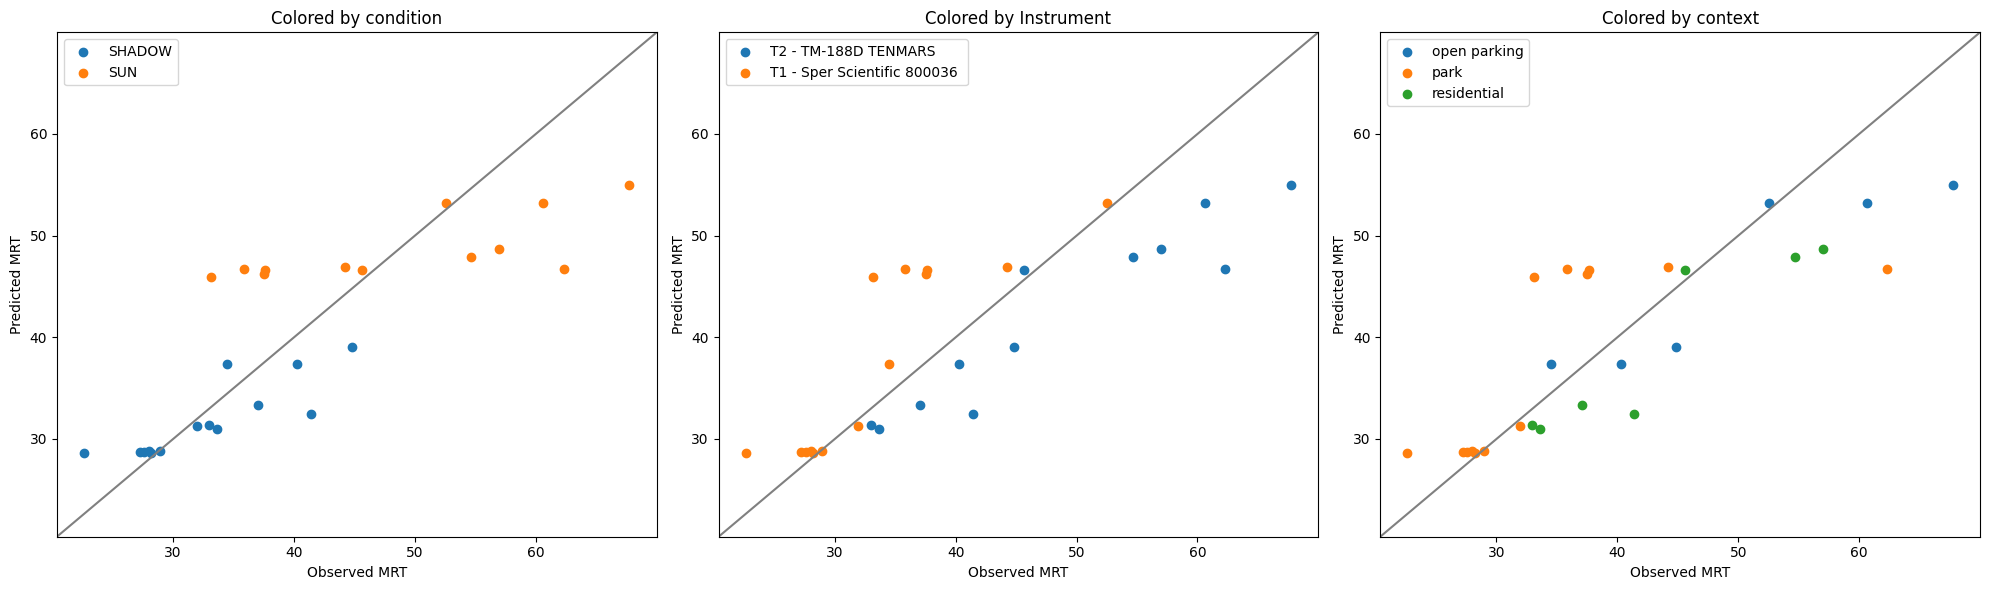

In [73]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Helper values
x = points_proj["MRT"]
y = points_proj["MRT_predicted"]

# 1) condition
for cond in points_proj["condition"].unique():
    mask = points_proj["condition"] == cond
    axes[0].scatter(x[mask], y[mask], label=cond)
axes[0].set_title("Colored by condition")
axes[0].set_xlabel("Observed MRT")
axes[0].set_ylabel("Predicted MRT")
axes[0].legend()

# 2) Instrument
for inst in points_proj["Instrument"].unique():
    mask = points_proj["Instrument"] == inst
    axes[1].scatter(x[mask], y[mask], label=inst)
axes[1].set_title("Colored by Instrument")
axes[1].set_xlabel("Observed MRT")
axes[1].set_ylabel("Predicted MRT")
axes[1].legend()

# 3) context
for ctx in points_proj["context"].unique():
    mask = points_proj["context"] == ctx
    axes[2].scatter(x[mask], y[mask], label=ctx)
axes[2].set_title("Colored by context")
axes[2].set_xlabel("Observed MRT")
axes[2].set_ylabel("Predicted MRT")
axes[2].legend()


# 1:1 reference line
for ax in axes.flat:
    lims = [
        min(ax.get_xlim()[0], ax.get_ylim()[0]),
        max(ax.get_xlim()[1], ax.get_ylim()[1])
    ]
    ax.plot(lims, lims, color="gray")
    ax.set_xlim(lims)
    ax.set_ylim(lims)

plt.tight_layout()
plt.show()